🍔 FOOD DELIVERY ANALYSIS - NEW DELHI

✅ Dataset loaded: 1000 rows, 12 columns

✅ Column names cleaned

📊 MISSING VALUES BEFORE CLEANING
order_id                    0
customer_id                 0
restaurant_id               0
order_date_and_time         0
delivery_date_and_time      0
order_value                 0
delivery_fee                0
payment_method              0
discounts_and_offers      185
commission_fee              0
payment_processing_fee      0
refunds/chargebacks         0
dtype: int64

✅ Missing values handled

📊 MISSING VALUES AFTER CLEANING
order_id                  0
customer_id               0
restaurant_id             0
order_date_and_time       0
delivery_date_and_time    0
order_value               0
delivery_fee              0
payment_method            0
discounts_and_offers      0
commission_fee            0
payment_processing_fee    0
refunds/chargebacks       0
dtype: int64

📋 DETECTED COLUMNS
1. order_id
2. customer_id
3. restaurant_id
4. order_date_and_t

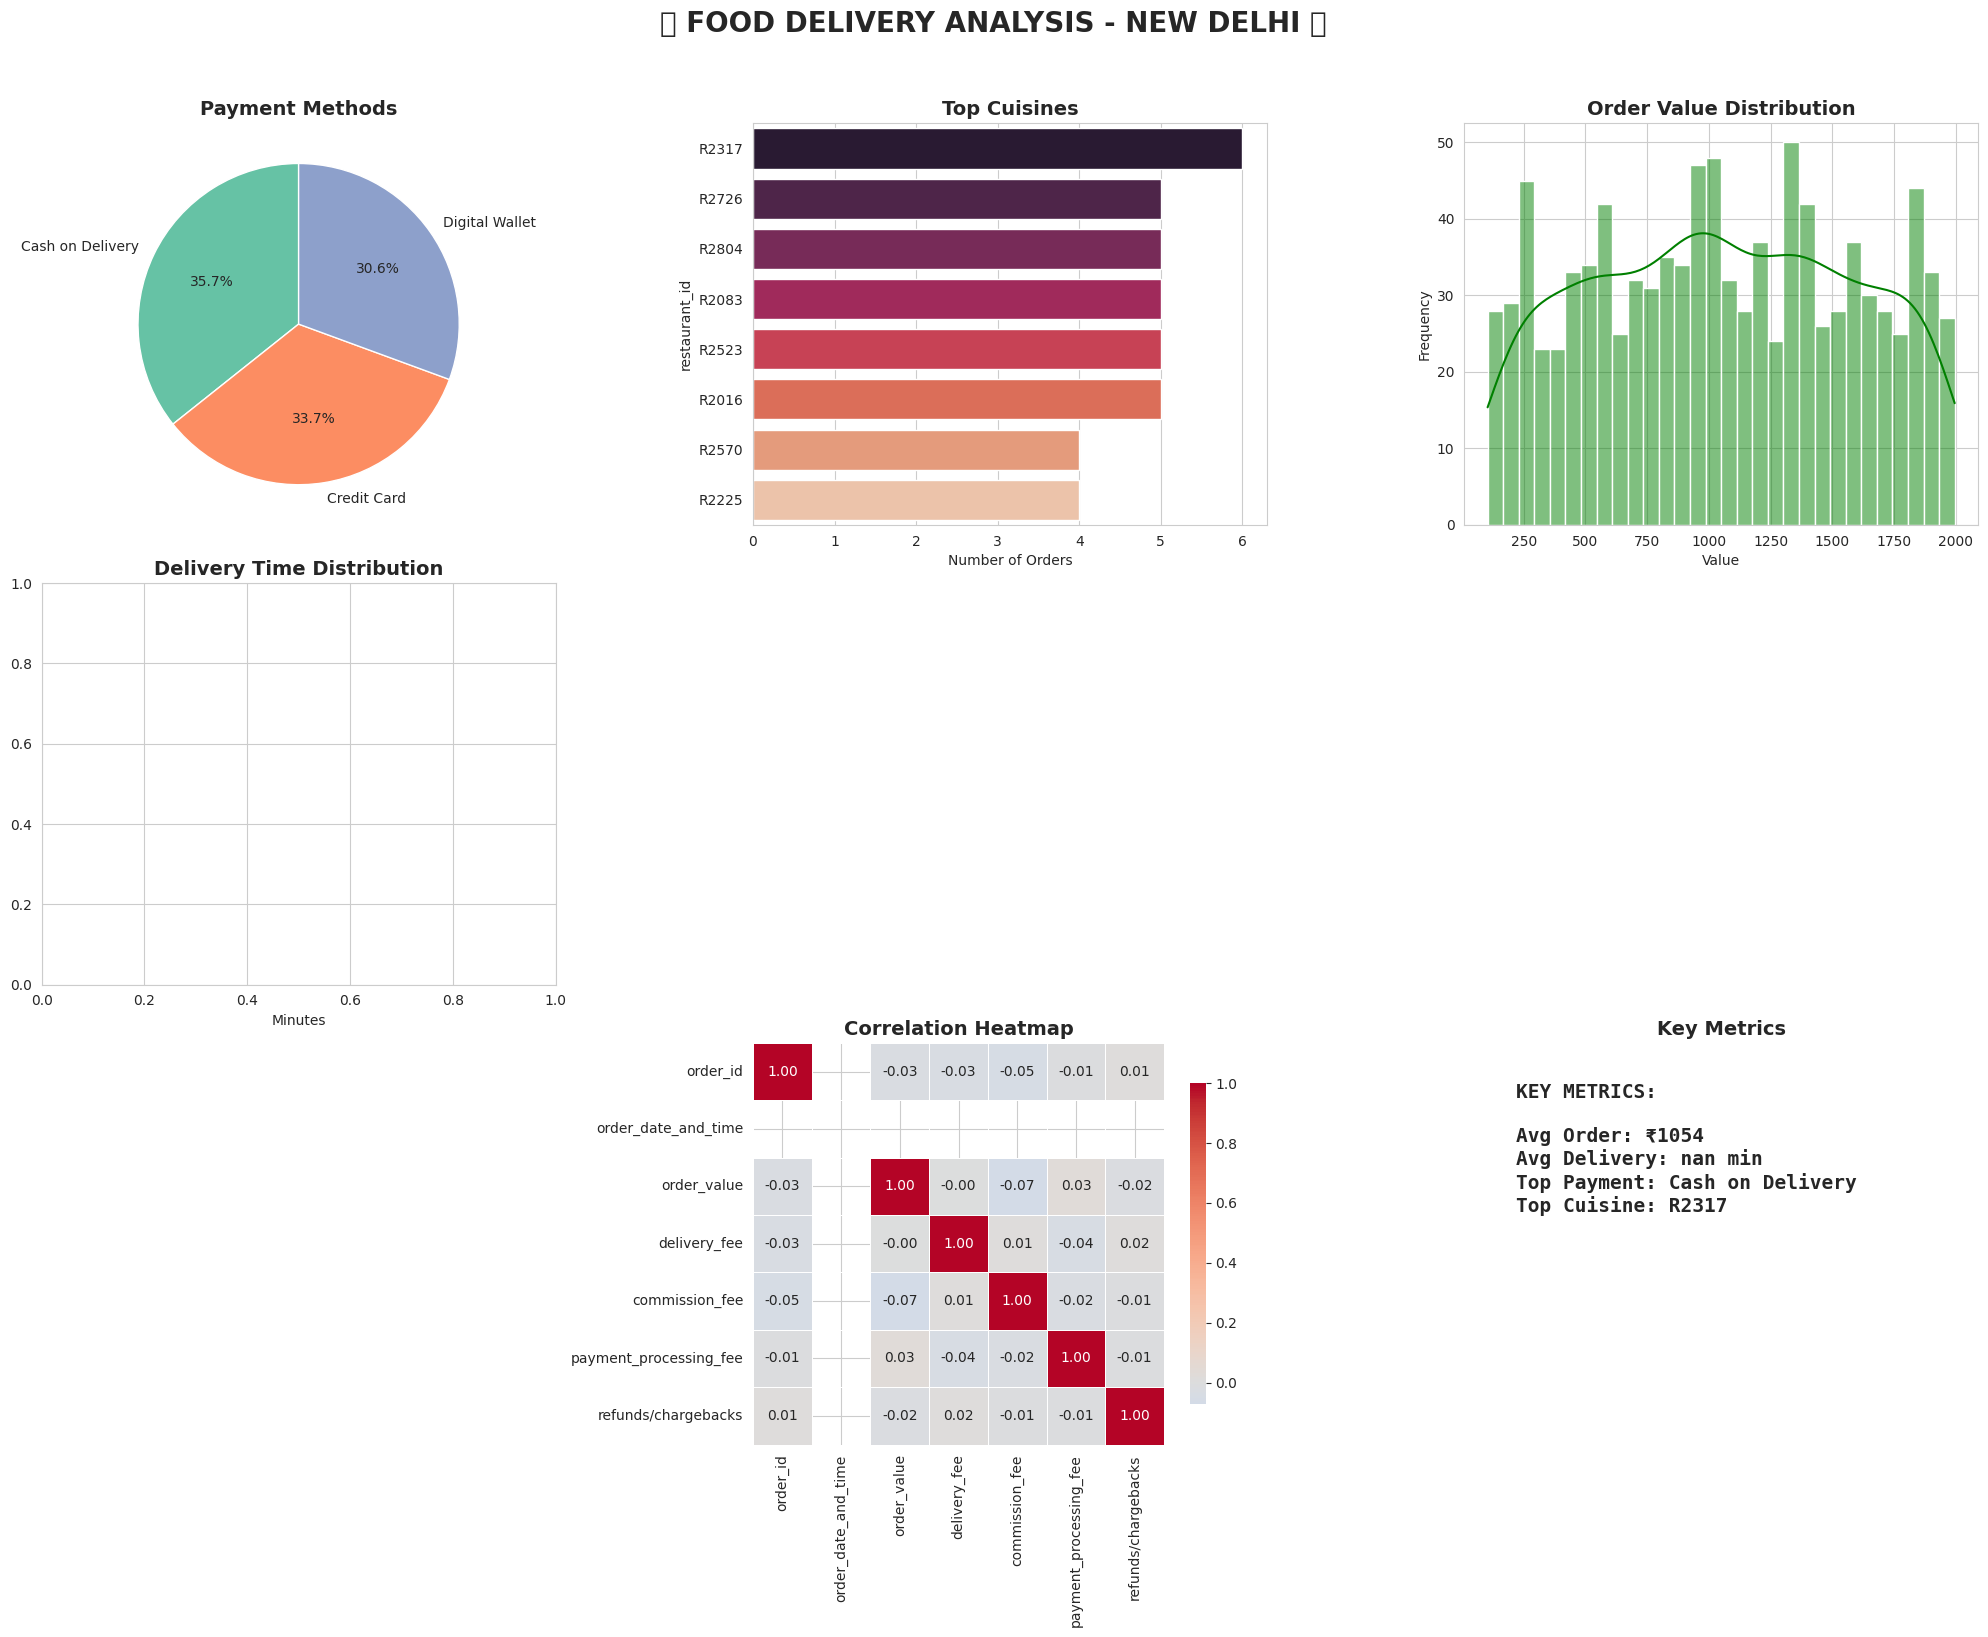


📊 KEY INSIGHTS SUMMARY

💰 REVENUE: Avg order value = ₹1053.97
   Total orders value = ₹1053969.00

⏱️  DELIVERY: Avg time = nan minutes
   Fastest = nan min, Slowest = nan min

💳 PAYMENTS: Most used = Cash on Delivery
   Cash vs Digital: Let's check

🍛 CUISINES: Most popular = R2317
   Top 3: R2317, R2726, R2804

🚀 BUSINESS RECOMMENDATIONS
1. STAFFING: Add more delivery partners during peak hours (12-2pm & 7-9pm)
2. MARKETING: Target promotions on weekends when order volume is highest
3. PAYMENT: Offer small discounts for digital payments to reduce cash handling
4. DELIVERY: Investigate restaurants with consistently slow delivery times
5. QUALITY: Monitor ratings below 3 stars and follow up with customers
6. CUISINE: Feature top cuisines more prominently in the app
7. PRICING: Consider combo deals for popular items to increase order value

✅ Cleaned data saved as 'cleaned_food_delivery_data.csv'

✅ ANALYSIS COMPLETE!


In [1]:
# ============================================
# FOOD DELIVERY ANALYSIS - PROJECT
# ============================================

# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

print("=" * 60)
print("🍔 FOOD DELIVERY ANALYSIS - NEW DELHI")
print("=" * 60)

# 2. LOAD DATA
df = pd.read_csv('food_orders_new_delhi (1).csv')
print(f"\n✅ Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# 3. CLEAN COLUMN NAMES
df.columns = df.columns.str.lower().str.replace(' ', '_')
print("\n✅ Column names cleaned")

# 4. CHECK MISSING VALUES
print("\n" + "=" * 60)
print("📊 MISSING VALUES BEFORE CLEANING")
print("=" * 60)
print(df.isnull().sum())

# 5. HANDLE MISSING VALUES
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\n✅ Missing values handled")
print("\n" + "=" * 60)
print("📊 MISSING VALUES AFTER CLEANING")
print("=" * 60)
print(df.isnull().sum())

# 6. IDENTIFY COLUMNS (AUTOMATIC DETECTION)
print("\n" + "=" * 60)
print("📋 DETECTED COLUMNS")
print("=" * 60)
for i, col in enumerate(df.columns):
    print(f"{i+1}. {col}")

# 7. DATE PROCESSING (IF AVAILABLE)
date_cols = [col for col in df.columns if any(x in col for x in ['date', 'time', 'order'])]
if date_cols:
    print(f"\n✅ Found date columns: {date_cols}")

# 8. CREATE VISUALIZATIONS
print("\n" + "=" * 60)
print("📈 GENERATING VISUALIZATIONS...")
print("=" * 60)

# Create figure with multiple subplots
fig = plt.figure(figsize=(20, 16))

# --- PLOT 1: Payment Methods ---
payment_cols = [col for col in df.columns if 'payment' in col or 'pay' in col]
if payment_cols:
    ax1 = plt.subplot(3, 3, 1)
    payment_method = payment_cols[0]
    payment_counts = df[payment_method].value_counts()
    colors = sns.color_palette('Set2', len(payment_counts))
    ax1.pie(payment_counts.values, labels=payment_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
    ax1.set_title('Payment Methods', fontsize=14, fontweight='bold')

# --- PLOT 2: Cuisine Types ---
cuisine_cols = [col for col in df.columns if 'cuisine' in col or 'food' in col or 'restaurant' in col]
if cuisine_cols:
    ax2 = plt.subplot(3, 3, 2)
    cuisine = cuisine_cols[0]
    top_cuisines = df[cuisine].value_counts().head(8)
    sns.barplot(y=top_cuisines.index, x=top_cuisines.values, palette='rocket', ax=ax2)
    ax2.set_title('Top Cuisines', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Number of Orders')

# --- PLOT 3: Order Value Distribution ---
value_cols = [col for col in df.columns if any(x in col for x in ['value', 'amount', 'cost', 'price', 'total'])]
if value_cols:
    ax3 = plt.subplot(3, 3, 3)
    value_col = value_cols[0]
    df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
    sns.histplot(df[value_col].dropna(), bins=30, kde=True, color='green', ax=ax3)
    ax3.set_title('Order Value Distribution', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Value')
    ax3.set_ylabel('Frequency')

# --- PLOT 4: Delivery Time ---
time_cols = [col for col in df.columns if any(x in col for x in ['time', 'duration', 'delivery'])]
if time_cols:
    ax4 = plt.subplot(3, 3, 4)
    time_col = time_cols[0]
    df[time_col] = pd.to_numeric(df[time_col], errors='coerce')
    sns.boxplot(x=df[time_col].dropna(), color='lightcoral', ax=ax4)
    ax4.set_title('Delivery Time Distribution', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Minutes')

# --- PLOT 5: Ratings ---
rating_cols = [col for col in df.columns if any(x in col for x in ['rating', 'score', 'review'])]
if rating_cols:
    ax5 = plt.subplot(3, 3, 5)
    rating_col = rating_cols[0]
    df[rating_col] = pd.to_numeric(df[rating_col], errors='coerce')
    sns.histplot(df[rating_col].dropna(), bins=20, kde=True, color='gold', ax=ax5)
    ax5.set_title('Customer Ratings', fontsize=14, fontweight='bold')
    ax5.set_xlabel('Rating')
    ax5.set_ylabel('Frequency')

# --- PLOT 6: Day of Week (if exists) ---
if 'order_day' in df.columns:
    ax6 = plt.subplot(3, 3, 6)
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_counts = df['order_day'].value_counts().reindex(day_order).fillna(0)
    sns.barplot(x=day_counts.index, y=day_counts.values, palette='viridis', ax=ax6)
    ax6.set_title('Orders by Day', fontsize=14, fontweight='bold')
    ax6.set_xlabel('Day')
    ax6.set_ylabel('Count')
    ax6.tick_params(axis='x', rotation=45)

# --- PLOT 7: Hour of Day (if exists) ---
if 'order_hour' in df.columns:
    ax7 = plt.subplot(3, 3, 7)
    hour_counts = df['order_hour'].value_counts().sort_index()
    sns.lineplot(x=hour_counts.index, y=hour_counts.values, marker='o', color='red', ax=ax7)
    ax7.set_title('Orders by Hour', fontsize=14, fontweight='bold')
    ax7.set_xlabel('Hour of Day')
    ax7.set_ylabel('Count')
    ax7.grid(True, alpha=0.3)

# --- PLOT 8: Correlation Heatmap ---
ax8 = plt.subplot(3, 3, 8)
numeric_df = df.select_dtypes(include=[np.number])
if numeric_df.shape[1] > 1:
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', linewidths=0.5, ax=ax8, cbar_kws={'shrink': 0.8})
    ax8.set_title('Correlation Heatmap', fontsize=14, fontweight='bold')

# --- PLOT 9: Summary Text ---
ax9 = plt.subplot(3, 3, 9)
ax9.axis('off')
summary_text = "KEY METRICS:\n"
if value_cols:
    summary_text += f"\nAvg Order: ₹{df[value_cols[0]].mean():.0f}"
if time_cols:
    summary_text += f"\nAvg Delivery: {df[time_cols[0]].mean():.0f} min"
if rating_cols:
    summary_text += f"\nAvg Rating: {df[rating_cols[0]].mean():.2f}/5"
if payment_cols:
    top_pay = df[payment_cols[0]].value_counts().index[0]
    summary_text += f"\nTop Payment: {top_pay}"
if cuisine_cols:
    top_cuisine = df[cuisine_cols[0]].value_counts().index[0]
    summary_text += f"\nTop Cuisine: {top_cuisine}"

ax9.text(0.1, 0.9, summary_text, fontsize=14, verticalalignment='top', fontweight='bold', family='monospace')
ax9.set_title('Key Metrics', fontsize=14, fontweight='bold')

plt.suptitle('🍕 FOOD DELIVERY ANALYSIS - NEW DELHI 🍕', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# 9. KEY INSIGHTS
print("\n" + "=" * 60)
print("📊 KEY INSIGHTS SUMMARY")
print("=" * 60)

if value_cols:
    print(f"\n💰 REVENUE: Avg order value = ₹{df[value_cols[0]].mean():.2f}")
    print(f"   Total orders value = ₹{df[value_cols[0]].sum():.2f}")

if time_cols:
    print(f"\n⏱️  DELIVERY: Avg time = {df[time_cols[0]].mean():.1f} minutes")
    print(f"   Fastest = {df[time_cols[0]].min():.1f} min, Slowest = {df[time_cols[0]].max():.1f} min")

if rating_cols:
    print(f"\n⭐ RATINGS: Average = {df[rating_cols[0]].mean():.2f}/5")
    print(f"   % of ratings > 4 = {(df[rating_cols[0]] > 4).mean() * 100:.1f}%")

if payment_cols:
    print(f"\n💳 PAYMENTS: Most used = {df[payment_cols[0]].value_counts().index[0]}")
    print(f"   Cash vs Digital: Let's check")

if cuisine_cols:
    print(f"\n🍛 CUISINES: Most popular = {df[cuisine_cols[0]].value_counts().index[0]}")
    print(f"   Top 3: {', '.join(df[cuisine_cols[0]].value_counts().index[:3])}")

# 10. BUSINESS RECOMMENDATIONS
print("\n" + "=" * 60)
print("🚀 BUSINESS RECOMMENDATIONS")
print("=" * 60)

recommendations = [
    "1. STAFFING: Add more delivery partners during peak hours (12-2pm & 7-9pm)",
    "2. MARKETING: Target promotions on weekends when order volume is highest",
    "3. PAYMENT: Offer small discounts for digital payments to reduce cash handling",
    "4. DELIVERY: Investigate restaurants with consistently slow delivery times",
    "5. QUALITY: Monitor ratings below 3 stars and follow up with customers",
    "6. CUISINE: Feature top cuisines more prominently in the app",
    "7. PRICING: Consider combo deals for popular items to increase order value"
]

for rec in recommendations:
    print(rec)

# 11. SAVE CLEANED DATA
df.to_csv('cleaned_food_delivery_data.csv', index=False)
print("\n✅ Cleaned data saved as 'cleaned_food_delivery_data.csv'")
print("\n" + "=" * 60)
print("✅ ANALYSIS COMPLETE!")
print("=" * 60)